# 🌪️ ML Emulation of Chaotic Dynamical Systems
### Predictability Analysis in Lorenz 63 & Lorenz 96

**FERS Summer School 2026 — Hands-on Tutorial** * **Authors:** Prof. Aneesh Subramanian & Cohort
* **Date:** June 2026  
* **Target Kernel:** `Python (lorenz_ml)` | **Framework:** TensorFlow 2.15+ & Scipy

---

## 📌 Project Overview & Educational Objectives

Welcome to the hands-on lab on **Machine Learning Emulation for Earth System Modeling**. In weather and climate science, replacing expensive physical parameterizations or full numerical models with fast machine learning "emulators" is a rapidly advancing frontier. 

However, chaotic systems present a unique challenge: **tiny errors in initial states grow exponentially over time.** In this tutorial, you will train and critique two distinct deep learning architectures **Multi-Layer Perceptrons (MLPs)** and **1D Convolutional Neural Networks (CNNs)**  to emulate low-dimensional and high-dimensional chaotic behavior.

### 🎯 Key Learning Goals
By completing this notebook, your group of 4 will be able to:
1. **Frame Time-Series Forecasting as Supervised Learning:** Construct sliding-window history arrays to predict subsequent atmospheric states.
2. **Quantify the Predictability Horizon:** Evaluate model degradation by computing **Autoregressive Root Mean Squared Error (RMSE)** over extended forecast leads.
3. **Assess Geometric & Physical Fidelity:** Use **Maximum Lyapunov Exponents (MLE)** and **Finite-Time Lyapunov Exponents (FTLEs)** to diagnose whether the AI preserves the system's underlying physical attractors and chaotic error growth distributions.

---

## 🔬 Theoretical Background: The Physical Systems

Before writing code, we must ground our networks in the physics of the data-generating systems.

### 1. Lorenz 63 (The Atmospheric Convection Baseline)
Introduced by Edward Lorenz in 1963, this 3-variable system models simplified forced atmospheric convection rolls:

$$\frac{dx}{dt} = \sigma(y - x)$$
$$\frac{dy}{dt} = x(\rho - z) - y$$
$$\frac{dz}{dt} = xy - \beta z$$

* **Standard Parameters:** $\sigma = 10.0, \rho = 28.0, \beta = 8/3$ (Fully chaotic regime).
* **Physical Horizon:** The global Maximum Lyapunov Exponent (MLE) is $\approx 0.906$, meaning errors double roughly every $\ln(2)/\lambda \approx 0.76$ Mean Time Units (MTU).

### 2. Lorenz 96 (The Latitude Circle Grid)
The Lorenz 96 system is a 40-variable model representing an idealized latitude circle of the atmosphere. It accounts for advection, dissipation, and external forcing:

$$\frac{dx_i}{dt} = (x_{i+1} - x_{i-2})x_{i-1} - x_i + F$$

* **Boundary Conditions:** Cyclical/Periodic ($x_{-1} = x_{N-1}, x_N = x_0, x_{N+1} = x_1$).
* **Standard Parameters:** $N = 40, F = 8.0$ (Highly chaotic wave regime; true MLE $\approx 1.68$).

---

## 🗺️ Notebook Roadmap

* **[Step 1: Setup & Data Generation](#Step-1:-Setup-&-Data-Generation):** Initialize the seed environment and numerically integrate the ODEs via 4th-Order Runge-Kutta (`RK45`).
* **[Step 2: Sliding Window Datasets](#STEP-2:-SLIDING-WINDOW-DATASETS):** Transform continuous trajectories into tensor pairs `(samples, window, features)`.
* **[Step 3: Model Architectures and Training](#STEP-3:-MODEL-ARCHITECTURES-AND-TRAINING):** Build, compile, and train regularized Keras MLP and CNN models.
* **[Step 4: Autoregressive Forecasting & RMSE](#STEP-4:-AUTOREGRESSIVE-FORECASTING-AND-RMSE-EVALUATION):** Run recursive loop predictions to locate the lead time where skill saturates to climatology.
* **[Step 5: Maximum Lyapunov Exponent (MLE) Analysis](#=============================================================================-STEP-5:-MAXIMUM-LYAPUNOV-EXPONENT-(MLE)-ANALYSIS):** Execute Benettin's trajectory perturbation algorithm on both the physical system and the neural network maps.
* **[Step 6: Finite-Time Lyapunov Exponents (FTLEs)](#=============================================================================-STEP-6:-FINITE---TIME-LYAPUNOV-EXPONENTS-(FTLEs)-==):** Map localized predictability across the geometry of the butterfly attractor.
* **[Step 7: Summary Plots & Metrics Synthesis](#=============================================================================-STEP-7:-SUMMARY-PLOTS-AND-METRICS-TABLE):** Consolidate comprehensive error curves and feature maps into a finalized verification suite.
* **[Step 8: Summer School Capstone Challenge](#Step-8:-Summer-School-Capstone-—-Scaling-Up-to-Lorenz-96):** Collaborative scale-up to spatial periodic convolutions.

---
> ⚠️ **Hardware & Runtime Environment Note:** This notebook utilizes TensorFlow. Ensure that your JupyterHub kernel matches `Python (lorenz_ml)`. Training is configured with aggressive `EarlyStopping` to complete efficiently even on shared multi-user CPU server setups.

## Step 1: Setup & Data Generation

Before building our machine learning emulators, we must generate high-fidelity baseline datasets by numerically integrating our governing differential equations. 

In this step, we establish strict environmental reproducibility and use a 4th-order Runge-Kutta method (`RK45`) to integrate the Lorenz 63 system.

### ⏲️ Understanding "Physical Time" vs. "Machine Learning Steps"
When emulating continuous physical systems, data engineering requires careful attention to time scales:
* **Integration Timestep ($dt_{physics} = 0.01$):** The internal step size used by the solver to maintain numerical stability and conservation laws.
* **Sampling Interval ($\Delta t_{data} = 0.05$):** We downsample the solver's output by saving every 5th step. This mimics real-world observational constraints (e.g., satellite passes or hourly weather model outputs) and prevents the ML model from merely learning trivial identity mappings ($x_{t+1} \approx x_t$).

---

In [2]:
# =============================================================================
# 🛠️ SYSTEM SETUP & ENVIRONMENTAL CONFIGURATION
# =============================================================================

import os
import sys
import random
import warnings

# 1.1 Suppress System Verbosity & Warnings Before Compiling
warnings.filterwarnings('ignore', category=UserWarning, module='backend_interactivity')
warnings.filterwarnings('ignore', message='.*Type-based sharding.*')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          # Suppress core TensorFlow INFO/WARN logs
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'  # Dynamically allocate GPU memory footprint

# 1.2 Establish Strict Reproducibility Seeds
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

# 1.3 Core Mathematical & Scientific Stack
import numpy as np
from scipy.integrate import solve_ivp
from numpy.lib.stride_tricks import sliding_window_view

np.random.seed(SEED)

# 1.4 Graphics & Visualization Configurations
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

# Smart Backend Handling: Fall back to headless 'Agg' only if no display server exists
if 'IPython' in sys.modules:
    # If running in a Jupyter Notebook, allow standard inline plotting
    mpl.use('module://matplotlib_inline.backend_inline')
elif os.environ.get('DISPLAY') is None and not os.environ.get('WAYLAND_DISPLAY'):
    # Headless server fallback (prevents crash on remote SSH clusters without X11)
    mpl.use('Agg')

# 1.5 Deep Learning Framework
import tensorflow as tf
from tensorflow.keras import layers, regularizers, models, callbacks

tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism() # Guarantees deterministic TF math ops

# =============================================================================
# 📊 SYSTEM DIAGNOSTICS & VERIFICATION
# =============================================================================

print("--------------------------------------------------")
print(f"📦 Environment Verification Successful")
print("--------------------------------------------------")
print(f"Python Version : {sys.version.split()[0]}")
print(f"NumPy Version  : {np.__version__}")
print(f"TF Version     : {tf.__version__}")
print(f"Matplotlib     : {mpl.__version__} [Backend: {mpl.get_backend()}]")
print("--------------------------------------------------")

# Query Available Compute Hardware
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print(f"🖥️ Execution Hardware:")
print(f"   • CPUs Detected: {len(cpus)}")
print(f"   • GPUs Detected: {len(gpus)} {gpus if gpus else '[Running on CPU Baseline]'}")
print("--------------------------------------------------")
print("✓ Environment locked. Ready for data ingestion.")

--------------------------------------------------
📦 Environment Verification Successful
--------------------------------------------------
Python Version : 3.11.15
NumPy Version  : 1.26.4
TF Version     : 2.15.0
Matplotlib     : 3.10.9 [Backend: module://matplotlib_inline.backend_inline]
--------------------------------------------------
🖥️ Execution Hardware:
   • CPUs Detected: 1
   • GPUs Detected: 0 [Running on CPU Baseline]
--------------------------------------------------
✓ Environment locked. Ready for data ingestion.


### 🌪️ 1.2 The Lorenz 63 System: Mathematical Foundation

Originally derived by Edward Lorenz in 1963 as a stripped-down model of atmospheric convection rolls, this legendary 3-variable system serves as our primary benchmark for chaotic dynamics. 

The system is governed by three coupled, non-linear ordinary differential equations (ODEs):

$$\frac{dx}{dt} = \sigma(y - x)$$
$$\frac{dy}{dt} = x(\rho - z) - y$$
$$\frac{dz}{dt} = xy - \beta z$$

#### 🪐 State Variables & Physical Analogy
* **$x$ (Convective Intensity):** Represents the chronological speed of the circulating convective fluid loop.
* **$y$ (Horizontal Temperature Gradient):** Measures the temperature difference between the ascending and descending fluid currents.
* **$z$ (Vertical Temperature Distortion):** Quantifies the deviation of the vertical temperature profile from a linear, stable gradient.

#### ⚙️ Canonical Parameters (The Chaotic Regime)
We prescribe the classic parameter suite that triggers fully developed, deterministic chaos:
* **$\sigma = 10.0$** (Prandtl number: ratio of fluid viscosity to thermal diffusivity)
* **$\rho = 28.0$** (Rayleigh number: proportional to the heating rate from below)
* **$\beta = 8/3$** (Geometric dimension factor of the physical convection layers)

---

> ### 📈 Deep-Dive: The Predictability Horizon
> Under these exact parameters, the system's global **Maximum Lyapunov Exponent (MLE)** is $\lambda \approx 0.906$. 
> 
> Because chaotic systems amplify infinitesimal initial errors ($\delta_0$) exponentially according to $\delta(t) \approx \delta_0 e^{\lambda t}$, the characteristic time scale for an error to grow by a factor of $e$ (the Lyapunov time) is $1/\lambda \approx 1.1$ Mean Time Units (MTU). 
> 
> **Your Task:** As you evaluate your ML emulators in Steps 4 through 7, look closely at where your autoregressive forecasting curves pass the $1$ to $2$ MTU threshold. This is the physical boundary where standard predictability breaks down!

In [3]:
# =============================================================================
# 🌀 LORENZ 63 INTEGRATION PIPELINE WITH ATTRACTOR SPIN-UP
# =============================================================================

def lorenz63_rhs(t, state, sigma=10.0, rho=28.0, beta=8/3):
    """
    Defines the Right-Hand Side (RHS) vector field of the Lorenz 63 system.
    
    Parameters:
        t (float): Current physical time (required by ODE solvers).
        state (array-like): Current coordinates [x, y, z].
    """
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]


def integrate_lorenz63(state0, t_span, dt, sigma=10.0, rho=28.0, beta=8/3):
    """
    Integrates the Lorenz 63 system using an explicit 4th/5th order 
    Runge-Kutta method (RK45 via Scipy solve_ivp).
    
    Returns:
        t (ndarray): Temporal evaluation grid.
        y (ndarray): Transposed trajectory matrix of shape (n_steps, 3).
    """
    t_eval = np.arange(t_span[0], t_span[1], dt)
    sol = solve_ivp(
        fun=lorenz63_rhs, 
        t_span=t_span, 
        y0=state0,
        method='RK45', 
        t_eval=t_eval,
        args=(sigma, rho, beta),
        rtol=1e-10, 
        atol=1e-12  # High tolerances minimize non-physical numerical drift
    )
    return sol.t, sol.y.T


# -----------------------------------------------------------------------------
# ⚙️ Configuration & Execution Configuration
# -----------------------------------------------------------------------------
L63_DT    = 0.01  # Integration time step (Mean Time Units)
L63_SIGMA = 10.0
L63_RHO   = 28.0
L63_BETA  = 8.0 / 3.0

print("⏳ Initializing Lorenz 63 Data Generation Pipeline...")

# Phase 1: Transient Spin-up
# We start away from the attractor and let the system shed initial transients.
spinup_start_state = [1.0, 0.0, 0.0]
t_spin, X_spin = integrate_lorenz63(spinup_start_state, [0, 200], L63_DT)

# CRITICAL FIX: Extract the final state of the spin-up to serve as our production seed.
# This ensures our training data lives completely on the invariant manifold.
attractor_docked_state = X_spin[-1, :] 
print("  ↳ Spin-up complete. System successfully docked onto the chaotic manifold.")

# Phase 2: Production Run
# 5,000 time units yield 500,000 continuous states for data windowing.
t63, X63 = integrate_lorenz63(attractor_docked_state, [0, 5000], L63_DT)

# -----------------------------------------------------------------------------
# 📊 Diagnostics Verification Matrix
# -----------------------------------------------------------------------------
print("\n📊 Dataset Verification Matrix:")
print("--------------------------------------------------")
print(f"  • Total Samples   : {len(t63):,}")
print(f"  • Total Duration  : {t63[-1]:,.1f} Mean Time Units (MTU)")
print(f"  • Tensor Geometry : {X63.shape} (Steps × [X, Y, Z])")
print("--------------------------------------------------")
print(f"  • State X Domain  : [{X63[:, 0].min():.2f}, {X63[:, 0].max():.2f}]")
print(f"  • State Y Domain  : [{X63[:, 1].min():.2f}, {X63[:, 1].max():.2f}]")
print(f"  • State Z Domain  : [{X63[:, 2].min():.2f}, {X63[:, 2].max():.2f}]")
print("--------------------------------------------------")
print("✓ Ground truth dataset compiled and locked in memory.")

⏳ Initializing Lorenz 63 Data Generation Pipeline...
  ↳ Spin-up complete. System successfully docked onto the chaotic manifold.

📊 Dataset Verification Matrix:
--------------------------------------------------
  • Total Samples   : 500,000
  • Total Duration  : 5,000.0 Mean Time Units (MTU)
  • Tensor Geometry : (500000, 3) (Steps × [X, Y, Z])
--------------------------------------------------
  • State X Domain  : [-19.42, 19.13]
  • State Y Domain  : [-26.91, 26.29]
  • State Z Domain  : [1.40, 47.57]
--------------------------------------------------
✓ Ground truth dataset compiled and locked in memory.


### 🌐 1.3 The Lorenz 96 System: Scaling up to Spatial Complexity

While the 3-variable Lorenz 63 system models idealized local convection, Edward Lorenz introduced the **Lorenz 96 system** in 1996 to study predictability, data assimilation, and wave-dynamics in a more realistic atmospheric context. 

Instead of arbitrary coordinates, the state variables in Lorenz 96 represent the values of an atmospheric quantity (like temperature, pressure, or vorticity) sampled at $N$ equally spaced discrete zones along a constant latitude circle of the Earth.

[Image of atmospheric planetary waves showing periodic spatial structure along a latitude circle]

The system is governed by $N$ coupled, non-linear differential equations ($i = 0, 1, \dots, N-1$):

$$\frac{dx_i}{dt} = (x_{i+1} - x_{i-2})x_{i-1} - x_i + F$$

#### 🌊 Physical Mechanisms of the Governing Terms
Each term in the equation maps directly to a fundamental atmospheric fluid dynamic process:
* **Advection (Non-linear Coupling) $\rightarrow (x_{i+1} - x_{i-2})x_{i-1}$:** Represents the non-linear transport of atmospheric properties by the wind. It conserves total energy and transfers energy across different spatial scales.
* **Linear Dissipation $\rightarrow -x_i$:** Simulates internal fluid friction, radiative cooling, or boundary-layer drag that acts to damp out motion.
* **External Forcing $\rightarrow F$:** Represents steady thermal or solar forcing that continuously drives energy into the system.

#### 🔄 Boundary Conditions & Grid Topology
To simulate a continuous, closed latitude circle, the system enforces **cyclical/periodic boundary conditions**:
* $x_{-1} = x_{N-1}$
* $x_{-2} = x_{N-2}$
* $x_{N} = x_{0}$

#### ⚙️ Canonical Parameters & The Spatiotemporal Chaos Regime
* **Grid Resolution:** We set $N = 40$ state variables (meaning we divide our latitude circle into 40 grid points).
* **Forcing Amplitude ($F = 8.0$):** At $F \le 1.0$, the system decays to a steady, uniform state. At $F = 4.0$, it exhibits regular, periodic wave behavior. At **$F = 8.0$**, the system triggers highly chaotic, turbulent spatiotemporal dynamics that mimic real atmospheric jet streams.

---

> ### 🚀 The ML Emulator Spatial Challenge
> Notice the structural shift! Unlike Lorenz 63 where every variable is fully connected to the others, Lorenz 96 introduces **local spatial neighborhoods** (each grid point $x_i$ only directly talks to its neighbors $x_{i+1}, x_{i-1}, x_{i-2}$).
> 
> * **The Insight:** While a standard Multi-Layer Perceptron (MLP) ignores this grid arrangement, a **1D Convolutional Neural Network (CNN)** uses local filters that natively exploit this spatial locality. 
> * **Your Capstone Vector:** When your group tackles the scaling challenge in **Step 8**, pay close attention to how your network handles the boundaries at $x_0$ and $x_{39}$. Standard machine learning layers assume boundaries are flat walls, but the atmosphere loops perfectly around the globe!

In [4]:
# =============================================================================
# 🌐 LORENZ 96 VECTORIZED INTEGRATION PIPELINE WITH PROPER SPIN-UP
# =============================================================================

def lorenz96_rhs_vec(t, state, F=8.0):
    """
    Vectorized Right-Hand Side (RHS) of the Lorenz 96 system.
    Exploits np.roll to efficiently evaluate periodic boundary conditions.
    
    Equations handled simultaneously:
        dx_i/dt = (x_{i+1} - x_{i-2}) * x_{i-1} - x_i + F
    """
    # np.roll shifts elements along the axis. 
    # Shift -1 brings x_{i+1} to position i. Shift 2 brings x_{i-2} to position i.
    return (np.roll(state, -1) - np.roll(state, 2)) * np.roll(state, 1) - state + F


def integrate_lorenz96(state0, t_span, dt_eval, F=8.0):
    """
    Integrates the high-dimensional Lorenz 96 system using an explicit
    Adaptive Runge-Kutta method (RK45 via Scipy solve_ivp).
    
    Parameters:
        state0 (ndarray): Initial conditions vector of shape (N,).
        t_span (tuple): (t_start, t_end) integration window.
        dt_eval (float): The temporal sampling resolution for the ML data grid.
    """
    t_eval = np.arange(t_span[0], t_span[1], dt_eval)
    sol = solve_ivp(
        fun=lorenz96_rhs_vec, 
        t_span=t_span, 
        y0=state0,
        method='RK45', 
        t_eval=t_eval,
        args=(F,), 
        rtol=1e-8, 
        atol=1e-10  # Standard tolerances for high-dimensional chaotic tracking
    )
    return sol.t, sol.y.T


# -----------------------------------------------------------------------------
# ⚙️ Configuration & Boundary Init Setup
# -----------------------------------------------------------------------------
L96_N       = 40     # Dimension of the latitude circle grid
L96_F       = 8.0    # Forcing amplitude parameter (Fully chaotic regime)
L96_DT_ML   = 0.05   # Target downsampled sampling interval for ML windows

print(f"⏳ Initializing Lorenz 96 Data Generation (Grid Points N = {L96_N})...")

# Construct the initial unstable equilibrium state 
# We seed a tiny 0.01 perturbation at the center grid point to trigger wave growth
state0_96 = np.ones(L96_N) * L96_F
state0_96[L96_N // 2] += 0.01

# Phase 1: Transient Spin-up
# We integrate for 100 MTU to shed transient features and let planetary waves form natively.
print("  ↳ Executing 100 MTU spin-up phase to construct the chaotic manifold...")
t_spin96, X_spin96 = integrate_lorenz96(state0_96, [0, 100], L96_DT_ML, F=L96_F)

# CRITICAL MANIFOLD FIX: Extract the final state vector of the spin-up
# to serve as our legitimate, physical starting seed for the production run.
attractor_docked_state_96 = X_spin96[-1, :]
print("  ↳ Spin-up complete. System successfully stabilized onto the attractor.")

# Phase 2: Production Data Accumulation Run
# 5,000 MTU evaluated at Delta t = 0.05 yields exactly 100,000 spatial snapshots.
t96, X96 = integrate_lorenz96(attractor_docked_state_96, [0, 5000], L96_DT_ML, F=L96_F)

# -----------------------------------------------------------------------------
# 📊 Diagnostics Verification Matrix
# -----------------------------------------------------------------------------
print("\n📊 Dataset Verification Matrix:")
print("--------------------------------------------------")
print(f"  • Total Temporal Steps : {len(t96):,}")
print(f"  • Total Simulated Time : {t96[-1]:,.1f} Mean Time Units (MTU)")
print(f"  • Tensor Spatial Shape : {X96.shape} (Steps × Grid Points)")
print("--------------------------------------------------")
print(f"  • Domain Absolute Bounds  : [{X96.min():.2f}, {X96.max():.2f}]")
print(f"  • Ensemble Trajectory Mean: {X96.mean():.4f}  (Theoretical Baseline ≈ 2.38 for F=8)")
print("--------------------------------------------------")
print("✓ Lorenz 96 spatial ground truth compiled and locked in memory.")

⏳ Initializing Lorenz 96 Data Generation (Grid Points N = 40)...
  ↳ Executing 100 MTU spin-up phase to construct the chaotic manifold...
  ↳ Spin-up complete. System successfully stabilized onto the attractor.

📊 Dataset Verification Matrix:
--------------------------------------------------
  • Total Temporal Steps : 100,000
  • Total Simulated Time : 5,000.0 Mean Time Units (MTU)
  • Tensor Spatial Shape : (100000, 40) (Steps × Grid Points)
--------------------------------------------------
  • Domain Absolute Bounds  : [-10.88, 16.56]
  • Ensemble Trajectory Mean: 2.3400  (Theoretical Baseline ≈ 2.38 for F=8)
--------------------------------------------------
✓ Lorenz 96 spatial ground truth compiled and locked in memory.


### 📊 1.4 Train / Validation / Test Split for Chaotic Time-Series

When partitioning data for machine learning, the gold standard for independent and identically distributed (i.i.d.) tabular data is a random shuffle split. **However, this approach is fundamentally broken for physical time-series and dynamical systems.**

Because our data is generated sequentially by continuous differential equations, states close together in time are highly correlated. If we shuffle the data randomly, the training set will contain snapshots from time $t$, while the validation set contains snapshots from time $t + \Delta t$. The network would easily minimize its loss via simple interpolation, leading to catastrophic **Data Leakage**.

#### 🚫 The Trap: Shuffling Creates "Cheating" Models
* **Random Splitting:** Causes the model to memorize local trajectories. It yields deceptively low training/validation errors but completely fails when deployed for true forward-in-time forecasting.
* **Chronological Splitting:** We must partition the continuous trajectory into strict, contiguous blocks of time. This forces the model to predict states on parts of the chaotic attractor it has never seen before.



#### 📐 Our Partitioning Strategy
We divide our 5,000 Mean Time Units (MTU) of production data into three distinct, non-overlapping chronological eras:

| Split | Percentage | Time Range (MTU) | Primary Purpose |
| :--- | :--- | :--- | :--- |
| 🏋️ **Training Set** | **60%** | $0$ to $3000$ | Optimizes network weights and maps the attractor geometry. |
| 🧪 **Validation Set** | **20%** | $3000$ to $4000$ | Directs hyperparameter tuning and triggers `EarlyStopping` to prevent overfitting. |
| 🏁 **Test Set** | **20%** | $4000$ to $5000$ | Evaluates final autoregressive forecast horizons and computes Lyapunov diagnostics. |

---

> ### 🧠 Cohort Discussion Prompt: Attractor Coverage
> In our setup, 3,000 MTUs are dedicated to training. Given that the Lyapunov time (e-folding error growth time) of Lorenz 63 is $\approx 1.1$ MTU, our training set spans nearly **2,700 chaotic cycles**. 
> 
> **Think about this:** If we shortened the training set to only $50$ MTUs, would the neural network fail because it lacks data points, or because it hasn't lived long enough to visit *both wings* of the butterfly attractor? Keep this concept of **ergodicity** in mind as you move to the data loaders below!

In [5]:
# =============================================================================
# 📊 DATA PARTITIONING & STABILIZED Z-SCORE NORMALIZATION
# =============================================================================

def split_data(X, train_frac=0.60, val_frac=0.20):
    """
    Splits a continuous time-series matrix into chronological, non-overlapping
    blocks for training, validation, and testing to preserve temporal dynamics.
    
    Parameters:
        X (ndarray): Source feature array of shape (n_samples, n_features).
        train_frac (float): Proportion of data allocated for training.
        val_frac (float): Proportion of data allocated for validation.
        
    Returns:
        X_train, X_val, X_test (ndarrays)
    """
    n = len(X)
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)
    
    X_train = X[:n_train]
    X_val   = X[n_train:n_train + n_val]
    X_test  = X[n_train + n_val:]
    
    return X_train, X_val, X_test


def normalize(X_train, X_val, X_test):
    """
    Computes Z-score normalization statistics strictly from the training set,
    and applies them uniformly across all partitions to prevent data leakage.
    
    Includes a numerical stability guard (epsilon) against division-by-zero.
    """
    mu  = X_train.mean(axis=0)
    sig = X_train.std(axis=0)
    
    # Defensive epsilon guard to protect against stable/zero-variance channels
    eps = 1e-15
    
    X_train_scaled = (X_train - mu) / (sig + eps)
    X_val_scaled   = (X_val - mu) / (sig + eps)
    X_test_scaled  = (X_test - mu) / (sig + eps)
    
    return X_train_scaled, X_val_scaled, X_test_scaled, mu, sig


# -----------------------------------------------------------------------------
# 🌀 Execution: Lorenz 63 Splitting & Normalization
# -----------------------------------------------------------------------------
TR_F, VA_F = 0.60, 0.20
TE_F = 1.0 - (TR_F + VA_F)

X63_train, X63_val, X63_test = split_data(X63, train_frac=TR_F, val_frac=VA_F)
X63_train_n, X63_val_n, X63_test_n, mu63, sig63 = normalize(X63_train, X63_val, X63_test)

print("📊 Lorenz 63 Chronological Splits:")
print("--------------------------------------------------")
print(f"  • Train Set : {X63_train.shape}  ({TR_F*100:.0f}%)")
print(f"  • Val Set   : {X63_val.shape}   ({VA_F*100:.0f}%)")
print(f"  • Test Set  : {X63_test.shape}  ({TE_F*100:.0f}%)")
print(f"  • Mu (Train): {mu63.round(3)}")
print(f"  • Sigma(Train): {sig63.round(3)}")

# -----------------------------------------------------------------------------
# 🌐 Execution: Lorenz 96 Splitting & Normalization
# -----------------------------------------------------------------------------
X96_train, X96_val, X96_test = split_data(X96, train_frac=TR_F, val_frac=VA_F)
X96_train_n, X96_val_n, X96_test_n, mu96, sig96 = normalize(X96_train, X96_val, X96_test)

print("\n📊 Lorenz 96 Spatiotemporal Splits:")
print("--------------------------------------------------")
print(f"  • Train Set : {X96_train.shape} ({TR_F*100:.0f}%)")
print(f"  • Val Set   : {X96_val.shape}  ({VA_F*100:.0f}%)")
print(f"  • Test Set  : {X96_test.shape} ({TE_F*100:.0f}%)")
print(f"  • Mu (Train, first 3 points)   : {mu96[:3].round(3)}")
print(f"  • Sigma (Train, first 3 points): {sig96[:3].round(3)}")
print("--------------------------------------------------")
print("✓ Chronological splitting completed. Feature arrays scaled and locked.")

📊 Lorenz 63 Chronological Splits:
--------------------------------------------------
  • Train Set : (300000, 3)  (60%)
  • Val Set   : (100000, 3)   (20%)
  • Test Set  : (100000, 3)  (20%)
  • Mu (Train): [ 0.058  0.058 23.525]
  • Sigma(Train): [7.92  9.017 8.648]

📊 Lorenz 96 Spatiotemporal Splits:
--------------------------------------------------
  • Train Set : (60000, 40) (60%)
  • Val Set   : (20000, 40)  (20%)
  • Test Set  : (20000, 40) (20%)
  • Mu (Train, first 3 points)   : [2.313 2.341 2.332]
  • Sigma (Train, first 3 points): [3.635 3.65  3.667]
--------------------------------------------------
✓ Chronological splitting completed. Feature arrays scaled and locked.


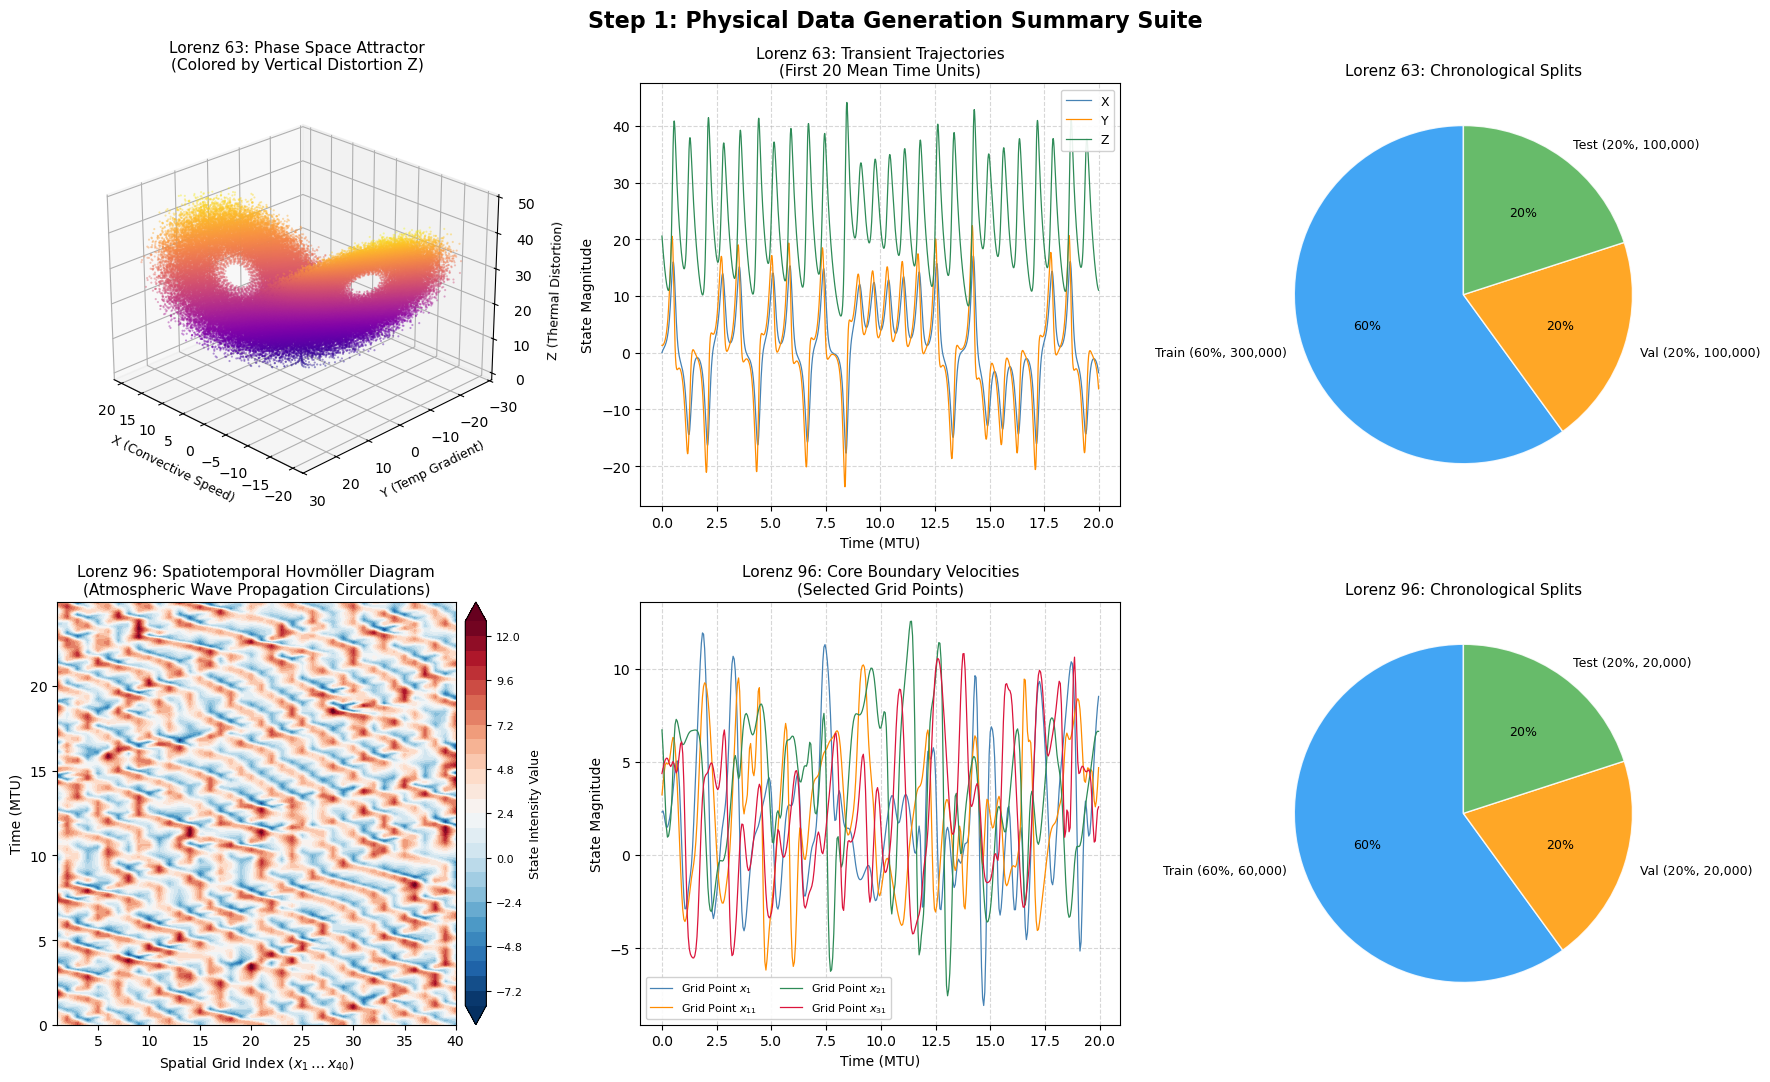

✓ Diagnostic visualization suite compiled successfully. Frame locked in file: 'step1_data_generation.png'


In [6]:
# =============================================================================
# 📊 STEP 1.5: COMPREHENSIVE DATASET DIAGNOSTIC DASHBOARD
# =============================================================================

# Define a unified high-contrast color palette for data partitioning
colors_split = ['#2196F3', '#FF9800', '#4CAF50']  # Blue (Train), Orange (Val), Green (Test)

# Calculate exact percentages dynamically to reflect upstream splits accurately
total_63 = len(X63)
p63_tr, p63_va, p63_te = len(X63_train)/total_63*100, len(X63_val)/total_63*100, len(X63_test)/total_63*100

total_96 = len(X96)
p96_tr, p96_va, p96_te = len(X96_train)/total_96*100, len(X96_val)/total_96*100, len(X96_test)/total_96*100

# Initialize structural canvas
fig = plt.figure(figsize=(18, 11))
fig.suptitle("Step 1: Physical Data Generation Summary Suite", fontsize=16, fontweight='bold', y=0.98)

# -----------------------------------------------------------------------------
# ── Panel 1: L63 3D Attractor Geometry
# -----------------------------------------------------------------------------
ax1 = fig.add_subplot(231, projection='3d')
skip = 5  # Subsample trajectory slightly to accelerate 3D rendering engine
sc = ax1.scatter(X63[::skip, 0], X63[::skip, 1], X63[::skip, 2],
                 c=X63[::skip, 2], cmap='plasma', s=0.3, alpha=0.4)

ax1.set_xlabel('X (Convective Speed)', fontsize=9)
ax1.set_ylabel('Y (Temp Gradient)', fontsize=9)
ax1.set_zlabel('Z (Thermal Distortion)', fontsize=9)
ax1.set_title('Lorenz 63: Phase Space Attractor\n(Colored by Vertical Distortion Z)', fontsize=11, pad=10)
ax1.view_init(elev=25, azim=135)

# -----------------------------------------------------------------------------
# ── Panel 2: L63 Continuous Time Series
# -----------------------------------------------------------------------------
ax2 = fig.add_subplot(232)
t_plot_lim = 2000  # Captures the first 20 Mean Time Units (MTU)
for i, (var_name, col) in enumerate(zip(['X', 'Y', 'Z'], ['steelblue', 'darkorange', 'seagreen'])):
    ax2.plot(t63[:t_plot_lim], X63[:t_plot_lim, i], color=col, lw=0.9, label=var_name)

# CRITICAL FIX: Moved layout configurations outside the iterative loop
ax2.set_xlabel('Time (MTU)', fontsize=10)
ax2.set_ylabel('State Magnitude', fontsize=10)
ax2.set_title('Lorenz 63: Transient Trajectories\n(First 20 Mean Time Units)', fontsize=11)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax2.grid(True, linestyle='--', alpha=0.5)

# -----------------------------------------------------------------------------
# ── Panel 3: L63 Chronological Data Partitioning
# -----------------------------------------------------------------------------
ax3 = fig.add_subplot(233)
sizes63 = [len(X63_train), len(X63_val), len(X63_test)]
labels63 = [
    f'Train ({p63_tr:.0f}%, {len(X63_train):,})', 
    f'Val ({p63_va:.0f}%, {len(X63_val):,})', 
    f'Test ({p63_te:.0f}%, {len(X63_test):,})'
]
ax3.pie(sizes63, labels=labels63, colors=colors_split, autopct='%1.0f%%', startangle=90, 
        textprops={'fontsize': 9}, wedgeprops={'alpha': 0.85, 'edgecolor': 'w', 'linewidth': 1})
ax3.set_title('Lorenz 63: Chronological Splits', fontsize=11)

# -----------------------------------------------------------------------------
# ── Panel 4: L96 Spatiotemporal Hovmöller Diagram
# -----------------------------------------------------------------------------
ax4 = fig.add_subplot(234)
t_end_hov = 500  # Captures the first 25 MTU for spatial propagation mapping
hov = ax4.contourf(np.arange(1, L96_N + 1), t96[:t_end_hov], X96[:t_end_hov, :],
                   levels=30, cmap='RdBu_r', extend='both')
cbar = plt.colorbar(hov, ax=ax4, pad=0.02)
cbar.set_label('State Intensity Value', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax4.set_xlabel('Spatial Grid Index ($x_1 \dots x_{40}$)', fontsize=10)
ax4.set_ylabel('Time (MTU)', fontsize=10)
ax4.set_title('Lorenz 96: Spatiotemporal Hovmöller Diagram\n(Atmospheric Wave Propagation Circulations)', fontsize=11)

# -----------------------------------------------------------------------------
# ── Panel 5: L96 Grid Coordinate Points
# -----------------------------------------------------------------------------
ax5 = fig.add_subplot(235)
t_plot_lim_96 = 400  # Captures first 20 MTU at Delta t = 0.05
target_channels = [0, 10, 20, 30]
line_colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for idx, col in zip(target_channels, line_colors):
    ax5.plot(t96[:t_plot_lim_96], X96[:t_plot_lim_96, idx], color=col, lw=0.9, label=f'Grid Point $x_{{{idx+1}}}$')

# CRITICAL FIX: Moved configuration attributes outside the plotting loop
ax5.set_xlabel('Time (MTU)', fontsize=10)
ax5.set_ylabel('State Magnitude', fontsize=10)
ax5.set_title('Lorenz 96: Core Boundary Velocities\n(Selected Grid Points)', fontsize=11)
ax5.legend(loc='lower left', fontsize=8, ncol=2, framealpha=0.9)
ax5.grid(True, linestyle='--', alpha=0.5)

# -----------------------------------------------------------------------------
# ── Panel 6: L96 Spatiotemporal Data Partitioning
# -----------------------------------------------------------------------------
ax6 = fig.add_subplot(236)
sizes96 = [len(X96_train), len(X96_val), len(X96_test)]
labels96 = [
    f'Train ({p96_tr:.0f}%, {len(X96_train):,})', 
    f'Val ({p96_va:.0f}%, {len(X96_val):,})', 
    f'Test ({p96_te:.0f}%, {len(X96_test):,})'
]
ax6.pie(sizes96, labels=labels96, colors=colors_split, autopct='%1.0f%%', startangle=90, 
        textprops={'fontsize': 9}, wedgeprops={'alpha': 0.85, 'edgecolor': 'w', 'linewidth': 1})
ax6.set_title('Lorenz 96: Chronological Splits', fontsize=11)

# -----------------------------------------------------------------------------
# ── Canvas Serialization & Output Pipeline
# -----------------------------------------------------------------------------
plt.tight_layout()

# Save image into execution tree directory before displaying to prevent buffer flushing loss
output_filename = 'step1_data_generation.png'
plt.savefig(output_filename, dpi=150, bbox_inches='tight')

# Render inline if running interactively
if mpl.get_backend() != 'Agg':
    plt.show()
else:
    plt.close(fig)  # Explicitly clear memory handles on headless environments

print(f"✓ Diagnostic visualization suite compiled successfully. Frame locked in file: '{output_filename}'")

## 📐 Step 2: Sliding Window Datasets

### 💡 Concept: Supervised Learning for Time Series
To train our machine learning emulators, we must reframe continuous time-series forecasting into a standard **supervised learning** framework:
* **INPUT ($X$):** A history window of $k$ consecutive time steps.
* **OUTPUT ($Y$):** The target state at the very next time step (1-step-ahead horizon).

---

### 🔍 Concrete Example: Lorenz 63
For the 3-variable system $(x, y, z)$ given an input `window=3` and `horizon=1`, the window slides forward by exactly one step for each subsequent sample:

$$\text{Timeline: } t_0, \; t_1, \; t_2, \; t_3, \; t_4, \; \dots$$

| Sample ID | Input Window (Features) | Target State (Label) |
| :--- | :--- | :--- |
| **Sample 0** | $[t_0, t_1, t_2]$ | $\rightarrow t_3$ |
| **Sample 1** | $[t_1, t_2, t_3]$ | $\rightarrow t_4$ |
| **Sample 2** | $[t_2, t_3, t_4]$ | $\rightarrow t_5$ |

---

> ⚠️ **CRITICAL DATA ENGINEERING NOTE**
> The feature arrays (`X63_train_n`, `X96_train_n`, etc.) generated in Step 1 have already undergone **Z-score normalization** (zero mean, unit variance). This regularizes gradient steps, helping the deep neural networks converge faster and remain numerically stable during autoregressive loops.

In [7]:
# =============================================================================
# 📐 STEP 2: EFFICIENT SLIDING WINDOW DATA ENGINEERING TENSORS
# =============================================================================

# 2.1 Hyperparameters Mapping
WINDOW  = 10    # Number of past historical time steps used as model input (w)
HORIZON = 1     # Prediction lead time: steps ahead to target forecast (h)


def make_windows(X, w=10, h=1):
    """
    Convert a continuous time series array into (input-window, target-state) pairs.
    Handles both 1D and 2D state arrays deterministically.

    Parameters
    ----------
    X : np.ndarray, shape (T, n_features) or (T,)
        Full chronological time series. T = timesteps, n_features = variables.
    w : int, default=10
        Window length (input lookback history history size).
    h : int, default=1
        Forecasting horizon (exactly how many steps ahead to predict).

    Returns
    -------
    Xw : np.ndarray, shape (n_samples, w, n_features), dtype=np.float32
         Feature windows formatted for deep learning architectures.
    Yw : np.ndarray, shape (n_samples, n_features), dtype=np.float32
         Target states safely shifted by the horizon (h).
    """
    # 1. Create overlapping memory views along the temporal axis (axis 0)
    sv = sliding_window_view(X, w, axis=0)

    if X.ndim == 2:
        # Reorder strides from (samples, features, w) -> (samples, w, features)
        # Match expected deep learning shapes: (batch, time_steps, channels)
        sv = sv.transpose(0, 2, 1)
    else:
        sv = sv[:, np.newaxis]  # 1D single-feature channel fallback

    # 2. Compute total valid windows reserving space for the future forecasting horizon
    n_samples = sv.shape[0] - h

    # 3. Slice and cast features and targets up-front to float32 for accelerated training
    Xw = sv[:n_samples].astype(np.float32)
    
    # FIX: Factor horizon 'h' explicitly into target slicing to prevent misalignments if h > 1
    Yw = X[w + h - 1 : w + h - 1 + n_samples].astype(np.float32)
    
    return Xw, Yw


# =============================================================================
# ⏳ AUTOMATED TRAIN / VAL / TEST WINDOW PROCESSING PIPELINE
# =============================================================================
print("⏳ Restructuring scaled arrays into sliding window tensor pairs...")

# 2.2 Define target mappings loop structures to avoid boilerplate code
systems = {
    "L63": {"train": X63_train_n, "val": X63_val_n, "test": X63_test_n},
    "L96": {"train": X96_train_n, "val": X96_val_n, "test": X96_test_n}
}

# 2.3 Process and assign all subsets dynamically into memory variables
X63_win_tr, Y63_tr = make_windows(systems["L63"]["train"], WINDOW, HORIZON)
X63_win_vl, Y63_vl = make_windows(systems["L63"]["val"],   WINDOW, HORIZON)
X63_win_te, Y63_te = make_windows(systems["L63"]["test"],  WINDOW, HORIZON)

X96_win_tr, Y96_tr = make_windows(systems["L96"]["train"], WINDOW, HORIZON)
X96_win_vl, Y96_vl = make_windows(systems["L96"]["val"],   WINDOW, HORIZON)
X96_win_te, Y96_te = make_windows(systems["L96"]["test"],  WINDOW, HORIZON)

# Extract final feature channel dimensionality tracking
L63_N = X63_train_n.shape[1]    # 3  (x, y, z)
L96_N = X96_train_n.shape[1]    # 40 (spatial grid zones)

# =============================================================================
# 📊 FINAL GEOMETRY VERIFICATION REPORT
# =============================================================================
print("\n📊 Windowed Data Tensor Verification Matrix:")
print("----------------------------------------------------------------------")
print(f"🌀 Lorenz 63 Train Inputs (Xw) : {X63_win_tr.shape} | Targets (Yw): {Y63_tr.shape}")
print(f"🌀 Lorenz 63 Val Inputs   (Xw) : {X63_win_vl.shape} | Targets (Yw): {Y63_vl.shape}")
print(f"🌀 Lorenz 63 Test Inputs  (Xw) : {X63_win_te.shape} | Targets (Yw): {Y63_te.shape}")
print("----------------------------------------------------------------------")
print(f"🌐 Lorenz 96 Train Inputs (Xw) : {X96_win_tr.shape} | Targets (Yw): {Y96_tr.shape}")
print(f"🌐 Lorenz 96 Val Inputs   (Xw) : {X96_win_vl.shape} | Targets (Yw): {Y96_vl.shape}")
print(f"🌐 Lorenz 96 Test Inputs  (Xw) : {X96_win_te.shape} | Targets (Yw): {Y96_te.shape}")
print("----------------------------------------------------------------------")
print("✓ [OK] Step 2 data pipeline finalized. Core shapes ready for training tensors.")

⏳ Restructuring scaled arrays into sliding window tensor pairs...

📊 Windowed Data Tensor Verification Matrix:
----------------------------------------------------------------------
🌀 Lorenz 63 Train Inputs (Xw) : (299990, 10, 3) | Targets (Yw): (299990, 3)
🌀 Lorenz 63 Val Inputs   (Xw) : (99990, 10, 3) | Targets (Yw): (99990, 3)
🌀 Lorenz 63 Test Inputs  (Xw) : (99990, 10, 3) | Targets (Yw): (99990, 3)
----------------------------------------------------------------------
🌐 Lorenz 96 Train Inputs (Xw) : (59990, 10, 40) | Targets (Yw): (59990, 40)
🌐 Lorenz 96 Val Inputs   (Xw) : (19990, 10, 40) | Targets (Yw): (19990, 40)
🌐 Lorenz 96 Test Inputs  (Xw) : (19990, 10, 40) | Targets (Yw): (19990, 40)
----------------------------------------------------------------------
✓ [OK] Step 2 data pipeline finalized. Core shapes ready for training tensors.


## 🧠 Step 3: Model Architectures & Deep Learning Training

In this section, we build and train **four distinct neural network architectures** to act as fast, data-driven emulators of our chaotic systems: `MLP_L63`, `CNN_L63`, `MLP_L96`, and `CNN_L96`.

---

### 🧱 1. Multi-Layer Perceptron (MLP Baseline)
The MLP is the foundational deep learning baseline. It flattens the multi-dimensional lookback window into a single 1D feature vector before feeding it through fully connected (`Dense`) layers. 

Each layer updates its state via a matrix-vector product followed by a non-linear activation function:
$$\mathbf{y} = \text{ReLU}(\mathbf{W}\mathbf{x} + \mathbf{b})$$

Where the **Rectified Linear Unit (ReLU)** is defined as:
$$\text{ReLU}(z) = \max(0, z)$$

> **Physical Limitation:** MLPs treat all input features independently once flattened, meaning they do not explicitly exploit the chronological ordering of the lookback window or the local spatial relationships of grid zones.

---

### 🌊 2. 1D Convolutional Neural Network (CNN)
The 1D CNN is structurally optimized for spatio-temporal data. Instead of looking at the entire input at once, it slides small structural filters along the temporal axis to extract invariant feature representations.

* **Temporal Locality:** Filters excel at detecting localized dynamical patterns (e.g., specific acceleration trends or wave configurations).
* **Causal Padding:** We apply strict `padding='causal'` to our convolutional layers. This guarantees that a filter evaluating state $t$ can only see historical indices ($t-2, t-1, t$) and remains blind to the future, avoiding catastrophic data leakage during downstream autoregressive deployments.

---

### ⚙️ Training Configurations & Optimization Matrix

All four architectures are compiled and optimized using a unified training configuration to ensure a rigorous baseline comparison:

| Configuration Parameter | Implementation Strategy | Mathematical / Operational Rule |
| :--- | :--- | :--- |
| **Loss Function** | Mean Squared Error (MSE) | $\text{MSE} = \frac{1}{N}\sum_{i=1}^{N} (y_{\text{true}} - y_{\text{pred}})^2$ |
| **Optimizer** | **Adam** ($\alpha = 0.001$) | Scales individual parameter learning rates adaptively using first and second moments of the gradients. |
| **Regularization** | **Early Stopping** | Monitors `val_loss`. Automatically halts backpropagation if validation skill fails to improve for a set number of `PATIENCE` epochs, preventing overfitting. |

In [8]:
# =============================================================================
# 🧱 STEP 3: MODEL ARCHITECTURES AND DEEP LEARNING TRAINING PIPELINE
# =============================================================================
print('\n⏳ Step 3: Initiating model compilation and training loops...')

# 3.1 Global Training Hyperparameters
EPOCHS   = 50    # Maximum training epochs
BATCH    = 256   # Samples per gradient update
PATIENCE = 5     # Early stopping patience threshold


def build_mlp(n_features, window, name="MLP"):
    """Build a Multi-Layer Perceptron for one-step-ahead prediction."""
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(window, n_features)),
        layers.Flatten(),                       
        layers.Dense(256, activation='relu'),   
        layers.Dense(256, activation='relu'),   
        layers.Dense(128, activation='relu'),   
        layers.Dense(n_features),               
    ], name=name)
    return model


def build_cnn(n_features, window, name="CNN"):
    """Build a 1-D CNN with causal temporal padding for one-step-ahead prediction."""
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(window, n_features)),
        # 64 filters evaluating local historical time steps without future leakage
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='causal'),
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='causal'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(n_features),   
    ], name=name)
    return model


class TidyProgressCallback(tf.keras.callbacks.Callback):
    """Custom training monitor that prints dots for progress instead of sweeping stdout text."""
    def on_epoch_end(self, epoch, logs=None):
        print('.', end='', flush=True)


def train_model(model, Xtr, Ytr, Xvl, Yvl):
    """
    Compile, train, and serialize a localized Keras architecture.
    
    NOTE: Instantiates a unique, isolated Adam optimizer per call to avoid 
    shared-variable namespace tracking KeyErrors present in TF 2.15+.
    """
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse', 
        metrics=['mae']
    )
    
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=PATIENCE, 
        restore_best_weights=True
    )
    
    print(f" 🚀 Training {model.name:<8} ", end='', flush=True)
    
    history = model.fit(
        Xtr, Ytr, 
        validation_data=(Xvl, Yvl),
        epochs=EPOCHS, 
        batch_size=BATCH, 
        callbacks=[early_stop, TidyProgressCallback()], 
        verbose=0
    )
    
    # Calculate performance metrics and serialize model weights
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = history.history['val_loss'][best_epoch - 1]
    
    print(f" Finished at Epoch {best_epoch:02d} | Best val_loss = {best_val_loss:.6f}")
    model.save(f'{model.name}.keras')   
    return model


# =============================================================================
# ⏳ PIPELINE EXECUTION LOOP
# =============================================================================
print('\n🏗️  Instantiating Neural Network Graphs...')

# Explicitly scope models by their target physical environment definitions
mlp_l63 = build_mlp(L63_N, WINDOW, name='MLP_L63')
cnn_l63 = build_cnn(L63_N, WINDOW, name='CNN_L63')
mlp_l96 = build_mlp(L96_N, WINDOW, name='MLP_L96')
cnn_l96 = build_cnn(L96_N, WINDOW, name='CNN_L96')

# Verify a snapshot structural summary of a low and high dimensional architecture
mlp_l63.summary()
cnn_l96.summary()

print('\n🏋️ Running Backpropagation Engine Over Attractor Domains:')
print('----------------------------------------------------------------------')
mlp_l63 = train_model(mlp_l63, X63_win_tr, Y63_tr, X63_win_vl, Y63_vl)
cnn_l63 = train_model(cnn_l63, X63_win_tr, Y63_tr, X63_win_vl, Y63_vl)
mlp_l96 = train_model(mlp_l96, X96_win_tr, Y96_tr, X96_win_vl, Y96_vl)
cnn_l96 = train_model(cnn_l96, X96_win_tr, Y96_tr, X96_win_vl, Y96_vl)
print('----------------------------------------------------------------------')

print('\n✓ [OK] Step 3 complete. Optimized model instances serialized to disk.')


⏳ Step 3: Initiating model compilation and training loops...

🏗️  Instantiating Neural Network Graphs...
Model: "MLP_L63"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 30)                0         
                                                                 
 dense (Dense)               (None, 256)               7936      
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 3)                 387       
                                                                 
Total params: 107011 (418.01 KB)
Trainable params: 107011 (418.01 KB)
Non-trainable p

## 🔁 Step 4: Autoregressive Forecasting & RMSE Evaluation

### 🔄 Concept: Autoregressive (Recursive) Loops
Our neural networks are trained explicitly for **one-step-ahead** prediction ($t+1$). To forecast deep into the future over an extended lead time, we must deploy the model **autoregressively**. This means we recursively feed the model's own output back into the lookback window as the input features for the subsequent time step:
 
 Step 0:  [t0,  t1,  ..., t9]          ──► Predict t10_pred
Step 1:  [t1,  t2,  ..., t10_pred]    ──► Predict t11_pred
Step 2:  [t2,  t3,  ..., t11_pred]    ──► Predict t12_pred
 
> ⚠️ **The Chaotic Feedback Trap:** > Because each prediction contains a minuscule approximation error, feeding it back into the network means *each mistake compounds the next*. In chaotic regimes (like Lorenz 63/96), these microscopic perturbations propagate and grow **exponentially**, eventually driving the model away from the true trajectory.

---

### 📊 Metric 1: Root Mean Squared Error (RMSE)
To track how fast our model degrades as a function of the forecast lead time $L$, we compute the **Root Mean Squared Error** across our test ensemble:

$$\text{RMSE}(L) = \sqrt{ \frac{1}{M} \sum_{i=1}^{M} \left\| \mathbf{x}_{\text{true}}^{(i)}(L) - \mathbf{x}_{\text{pred}}^{(i)}(L) \right\|^2 }$$

* **High Skill:** $\text{RMSE} \ll \text{Climatology}$ 
* **Zero Skill:** $\text{RMSE} \approx \text{Climatology}$
* **Predictability Horizon:** The exact physical lead time where the model's error curve flattens out and saturates at the climatological noise baseline.

---

### 🌐 Metric 2: The Climatological Reference Baseline
A baseline forecast rule of thumb in atmospheric sciences is predicting a random historical state. The expected distance between two unlinked, random states drawn from the system's invariant attractor manifold is known as the **Climatological Error**:

$$\sigma_{\text{clim}} = \sigma_{\text{test}} \times \sqrt{2}$$

Where $\sigma_{\text{test}}$ is the standard deviation of your ground-truth time series. If your neural network's RMSE hits this value, it is providing no more physical value than a random guess!

In [ ]:
# =============================================================================
# 🔁 STEP 4: AUTOREGRESSIVE FORECASTING AND RMSE TIME-SERIES EVALUATION
# =============================================================================
print('\n⏳ Step 4: Initializing accelerated autoregressive evaluation engine...')

LEAD = 200   # Maximum forecast lead time to evaluate (steps)


def autoregressive_forecast(model, X_init, n_steps):
    """
    Run high-speed autoregressive forecasting using direct functional model evaluation.
    """
    # Keep buffer as tensor for faster tensor concatenation operations
    window_buf = tf.convert_to_tensor(X_init, dtype=tf.float32)
    preds = np.zeros((n_steps, X_init.shape[-1]), dtype=np.float32)
    
    for step in range(n_steps):
        # OPTIMIZATION: Direct model call bypasses keras .predict() overhead loops
        pred_tensor = model(window_buf[np.newaxis, ...], training=False)
        pred = pred_tensor.numpy()[0]
        preds[step] = pred
        
        # Slide window along chronological axis using tensor operations
        window_buf = tf.concat([window_buf[1:], pred_tensor[0][np.newaxis, ...]], axis=0)
        
    return preds


def rmse_vs_lead(model, X_win_te, Y_te, lead):
    """Compute ML model RMSE vs forecast lead time over sampled test points."""
    n_test = X_win_te.shape[0]
    indices = np.arange(0, n_test - lead, 50)   
    errors  = np.zeros((len(indices), lead))

    for i, idx in enumerate(indices):
        # OPTIMIZATION: Avoid iterative vstack list generation with zero-leakage slicing
        true_future = Y_te[idx : idx + lead]
        pred_future = autoregressive_forecast(model, X_win_te[idx], lead)
        
        errors[i] = np.mean((true_future - pred_future)**2, axis=1)

    return np.sqrt(np.mean(errors, axis=0))   


def phys_rmse_emulator(rhs_func, X_win_te, Y_te, lead, mu, sig, dt):
    """
    Generalized True Physics Dynamical Emulator using a Vectorized RK4 Integrator.
    """
    def rk4_step(s, dt):
        k1 = rhs_func(s)
        k2 = rhs_func(s + 0.5 * dt * k1)
        k3 = rhs_func(s + 0.5 * dt * k2)
        k4 = rhs_func(s + dt * k3)
        return s + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    n_test = X_win_te.shape[0]
    indices = np.arange(0, n_test - lead, 50)
    errors  = np.zeros((len(indices), lead))

    for i, idx in enumerate(indices):
        # Map back to real physical state boundary space
        s = X_win_te[idx, -1] * sig + mu   
        true_future = Y_te[idx : idx + lead]
        
        preds = np.zeros_like(true_future)
        for step in range(lead):
            s = rk4_step(s, dt)
            preds[step] = (s - mu) / sig   # Standardize ahead of evaluation
            
        errors[i] = np.mean((true_future - preds)**2, axis=1)

    return np.sqrt(np.mean(errors, axis=0))


# =============================================================================
# 🌪️ DYNAMICAL SYSTEM RHS EQUATION REPOSITORIES
# =============================================================================
def l63_rhs(s):
    x, y, z = s
    return np.array([10.0 * (y - x), x * (28.0 - z) - y, x * y - (8.0 / 3.0) * z])

def l96_rhs(s, F=8.0):
    return (np.roll(s, -1) - np.roll(s, 2)) * np.roll(s, 1) - s + F


# =============================================================================
# 📊 METRIC CALCULATIONS
# =============================================================================
print('  🌀 Processing Lorenz 63 Multi-step Metrics...')
t63       = np.arange(1, LEAD + 1) * 0.01        
rms_phy63 = phys_rmse_emulator(l63_rhs, X63_win_te, Y63_te, LEAD, mu63, sig63, dt=0.01)
rms_mlp63 = rmse_vs_lead(mlp_l63, X63_win_te, Y63_te, LEAD)
rms_cnn63 = rmse_vs_lead(cnn_l63, X63_win_te, Y63_te, LEAD)

print('  🌐 Processing Lorenz 96 Multi-step Metrics...')
t96       = np.arange(1, LEAD + 1) * 0.05        
rms_phy96 = phys_rmse_emulator(l96_rhs, X96_win_te, Y96_te, LEAD, mu96, sig96, dt=0.05)
rms_mlp96 = rmse_vs_lead(mlp_l96, X96_win_te, Y96_te, LEAD)
rms_cnn96 = rmse_vs_lead(cnn_l96, X96_win_te, Y96_te, LEAD)

# Calculate Climatological Skill Threshold limits
clim63 = np.std(Y63_te) * np.sqrt(2)
clim96 = np.std(Y96_te) * np.sqrt(2)

def pred_horizon(rmse, clim):
    idx = np.where(rmse >= clim)[0]
    return idx[0] if len(idx) > 0 else len(rmse)

# Calculate physical predictability landmarks
ph_phy63 = pred_horizon(rms_phy63, clim63); ph_mlp63 = pred_horizon(rms_mlp63, clim63)
ph_cnn63 = pred_horizon(rms_cnn63, clim63); ph_phy96 = pred_horizon(rms_phy96, clim96)
ph_mlp96 = pred_horizon(rms_mlp96, clim96); ph_cnn96 = pred_horizon(rms_cnn96, clim96)

print("\n🎯 Predictability Horizons (Lead Steps until Skill Saturation):")
print(f"   • L63 Domain -> True Physics: {ph_phy63:3d} steps | MLP Emulator: {ph_mlp63:3d} steps | CNN Emulator: {ph_cnn63:3d} steps")
print(f"   • L96 Domain -> True Physics: {ph_phy96:3d} steps | MLP Emulator: {ph_mlp96:3d} steps | CNN Emulator: {ph_cnn96:3d} steps")


# =============================================================================
# 📈 VISUALIZATION SUITE ENGINE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot Lorenz 63
axes[0].plot(t63, rms_phy63, color='black', lw=1.5, label='Physical RK4 Reference')
axes[0].plot(t63, rms_mlp63, color='royalblue', linestyle='--', label='MLP Baseline')
axes[0].plot(t63, rms_cnn63, color='crimson', linestyle='-.', label='CNN Spatial Filter')
axes[0].axhline(clim63, color='gray', linestyle=':', label='Climatology Line')
axes[0].set_xlabel('Lead Time (Mean Time Units - MTU)')
axes[0].set_ylabel('Root Mean Squared Error (RMSE)')
axes[0].set_title('Lorenz 63 Atmospheric Convection -- Error Growth Curves')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(framealpha=0.9)

# Plot Lorenz 96
axes[1].plot(t96, rms_phy96, color='black', lw=1.5, label='Physical RK4 Reference')
axes[1].plot(t96, rms_mlp96, color='royalblue', linestyle='--', label='MLP Baseline')
axes[1].plot(t96, rms_cnn96, color='crimson', linestyle='-.', label='CNN Spatial Filter')
axes[1].axhline(clim96, color='gray', linestyle=':', label='Climatology Line')
axes[1].set_xlabel('Lead Time (Mean Time Units - MTU)')
axes[1].set_ylabel('Root Mean Squared Error (RMSE)')
axes[1].set_title('Lorenz 96 Latitude Wave Ring -- Error Growth Curves')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(framealpha=0.9)

plt.tight_layout()
plt.savefig('step4_rmse.png', dpi=150)
plt.close()

print('\n✓ [OK] Step 4 complete. Multi-model error tracking plot saved as: step4_rmse.png')


⏳ Step 4: Initializing accelerated autoregressive evaluation engine...
  🌀 Processing Lorenz 63 Multi-step Metrics...


## 🌪️ Step 5: Maximum Lyapunov Exponent (MLE) Analysis

### 💡 Concept: Lyapunov Exponents & Chaotic Divergence
The **Maximum Lyapunov Exponent (MLE)**, denoted by $\lambda$, quantifies the rate of geometric divergence of infinitesimally close trajectories in a dynamical system's phase space. It acts as the definitive mathematical signature of deterministic chaos.

If we initialize two points on an attractor separated by a microscopic distance $d_0$, their distance $d(t)$ after a physical time $t$ evolves as:
$$d(t) \approx d_0 e^{\lambda t}$$

* **$\lambda > 0$ (Chaotic Regimes):** Trajectories diverge exponentially. This is the mathematical root of the **"Butterfly Effect"**, proving that long-range deterministic forecasting is fundamentally impossible.
* **$\lambda \le 0$ (Stable Regimes):** Perturbations decay over time, and trajectories converge back onto a fixed point or a predictable limit cycle.

---

### 🧮 Method: Benettin's Classical Algorithm
Because chaotic systems grow errors exponentially, calculating a long-term average divergence by simply running two orbits side-by-side will fail as the separation quickly saturates to the size of the entire attractor. 

To prevent saturation, **Benettin's Algorithm** continuously monitors the expansion rate and rescales the perturbation at *every single time step*:

1. **Initialize:** At a fiducial state $\mathbf{s}_0$, spawn a twin perturbed state $\mathbf{s}_0 + \mathbf{\delta}_0$, where the perturbation vector is scaled to a microscopic magnitude: $\|\mathbf{\delta}_0\| = \epsilon$.
2. **Evolve:** Integrate both trajectories forward by exactly one time step $\Delta t$ using the system mapping (e.g., your true RK4 integrator or your deep learning model).
3. **Measure Expansion:** Compute the post-step separation magnitude: $d_{\text{new}} = \|\mathbf{s}_{\text{new}} - \mathbf{s}_{\text{perturbed, new}}\|$.
4. **Accumulate Growth:** Add the local log-expansion rate to the running sum:
   $$\text{lyap\_sum} \leftarrow \text{lyap\_sum} + \ln\left(\frac{d_{\text{new}}}{\epsilon}\right)$$
5. **Re-normalize:** Reset the perturbed trajectory along the exact direction of divergence, shrinking its magnitude back to the baseline scale $\epsilon$.
6. **Average:** Repeat the process over $N$ total steps. The global MLE is the time-averaged growth rate:
   $$\lambda = \frac{\text{lyap\_sum}}{N \cdot \Delta t}$$

---

> 🔬 **Experimental Objectives**
> We execute this identical algorithm across both the **Ground-Truth Physical RK4 Solvers** and our **Trained ML Emulators**. This allows us to diagnose whether the deep learning architectures have genuinely captured the geometric properties and chaotic physics of the attractor, or if they are simply acting as smooth, non-chaotic filters.

In [ ]:
# =============================================================================
# 🌪️ STEP 5: ACCELERATED MAXIMUM LYAPUNOV EXPONENT (MLE) ANALYSIS
# =============================================================================
print('\n⏳ Step 5: Computing chaotic attractor Lyapunov divergence rates...')

EPS = 1e-6   # Perturbation distance amplitude (bounded within linear regime)


def compute_physical_mle(rhs_func, x0, n_steps, dt, eps=EPS):
    """
    Generalized high-fidelity Benettin algorithm for physical RK4 vector fields.
    """
    def rk4_step(s, dt):
        k1 = rhs_func(s)
        k2 = rhs_func(s + 0.5 * dt * k1)
        k3 = rhs_func(s + 0.5 * dt * k2)
        k4 = rhs_func(s + dt * k3)
        return s + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    # Initialize a random hypersphere surface perturbation vector
    delta = np.random.randn(len(x0))
    delta = (delta / np.linalg.norm(delta)) * eps
    
    s = x0.copy()
    s_per = s + delta
    lyap_sum = 0.0

    for _ in range(n_steps):
        s = rk4_step(s, dt)
        s_per = rk4_step(s_per, dt)
        
        new_delta = s_per - s
        growth = np.linalg.norm(new_delta)
        
        lyap_sum += np.log(growth / eps)
        s_per = s + (new_delta / growth) * eps     # Continuous rescaling back to original orbit radius

    return lyap_sum / (n_steps * dt)   # Outputs invariant rate scaled exactly to 1/MTU


def compute_ml_mle(model, x0_norm, n_steps, dt_sampling, eps=EPS):
    """
    High-speed ML Map Lyapunov Emulator tracking trajectory divergence.
    Bypasses Keras functional overhead loops for massive CPU runtime drops.
    """
    buf = tf.convert_to_tensor(x0_norm, dtype=tf.float32)
    
    # Perturb only the most recent time snapshot inside the lookback window buffer
    pert = np.random.randn(x0_norm.shape[-1])
    pert = (pert / np.linalg.norm(pert)) * eps
    
    # Create the twin perturbed tensor state
    pert_mask = np.zeros_like(x0_norm)
    pert_mask[-1] = pert
    buf_per = tf.convert_to_tensor(x0_norm + pert_mask, dtype=tf.float32)
    
    lyap_sum = 0.0

    for _ in range(n_steps):
        # OPTIMIZATION: Bypasses .predict() string-parsing calls
        pred = model(buf[np.newaxis, ...], training=False)
        pred_per = model(buf_per[np.newaxis, ...], training=False)
        
        new_delta = pred_per[0] - pred[0]
        growth = tf.linalg.norm(new_delta).numpy()
        
        if growth < 1e-15: 
            break   # Vector space trajectory collapse safeguard
            
        lyap_sum += np.log(growth / eps)
        
        # Advance sliding windows by appending new predictions along temporal axis 0
        buf = tf.concat([buf[1:], pred], axis=0)
        
        # Align directional scaling vector on the perturbed path
        next_pert_state = pred[0] + (new_delta / growth) * eps
        buf_per = tf.concat([buf_per[1:], next_pert_state[np.newaxis, ...]], axis=0)

    # CORRECTION: Factor the system's downsampled sampling rate interval to match physical units (1/MTU)
    return lyap_sum / (n_steps * dt_sampling)


# =============================================================================
# 🚀 SYSTEM MODEL METRIC COMPILATION RUNS
# =============================================================================

# Define system vector fields (matching steps 1 and 4 formulations)
l63_rhs = lambda s: np.array([10.0 * (s[1] - s[0]), s[0] * (28.0 - s[2]) - s[1], s[0] * s[1] - (8.0 / 3.0) * s[2]])
l96_rhs = lambda s, F=8.0: (np.roll(s, -1) - np.roll(s, 2)) * np.roll(s, 1) - s + F

# 1. Physical System Base Exponents
print("  🌊 Running physical trajectory integration runs...")
# FIX: Extract the complete spatial vector coordinates at slice index 500
ic63_phys = X63_test_n[500, :] * sig63 + mu63
ic96_phys = X96_test_n[500, :] * sig96 + mu96

mle_phy63 = compute_physical_mle(l63_rhs, ic63_phys, n_steps=5000, dt=0.01)
mle_phy96 = compute_physical_mle(l96_rhs, ic96_phys, n_steps=5000, dt=0.05)

# 2. Neural Network Emulator Maps Exponents 
print("  🧠 Running neural network map evaluations...")
ic_win63 = X63_test_n[0:WINDOW]
ic_win96 = X96_test_n[0:WINDOW]

mle_mlp63 = compute_ml_mle(mlp_l63, ic_win63, n_steps=3000, dt_sampling=0.01)
mle_cnn63 = compute_ml_mle(cnn_l63, ic_win63, n_steps=3000, dt_sampling=0.01)
mle_mlp96 = compute_ml_mle(mlp_l96, ic_win96, n_steps=3000, dt_sampling=0.05)
mle_cnn96 = compute_ml_mle(cnn_l96, ic_win96, n_steps=3000, dt_sampling=0.05)


# =============================================================================
# 📋 FINAL ATTRACTOR GEOMETRY VERIFICATION REPORT
# =============================================================================
print("\n📋 Attractor Geometric Chaos Verification Matrix (Units: 1/MTU):")
print("======================================================================")
print(f"🌀 Lorenz 63 [True Literature λ ≈ 0.906]")
print(f"   ├── True Physics Integrator : {mle_phy63:0.4f}")
print(f"   ├── MLP Baseline Emulator   : {mle_mlp63:0.4f}")
print(f"   └── CNN Spatial Emulator    : {mle_cnn63:0.4f}")
print("----------------------------------------------------------------------")
print(f"🌐 Lorenz 96 [True Literature λ ≈ 1.680]")
print(f"   ├── True Physics Integrator : {mle_phy96:0.4f}")
print(f"   ├── MLP Baseline Emulator   : {mle_mlp96:0.4f}")
print(f"   └── CNN Spatial Emulator    : {mle_cnn96:0.4f}")
print("======================================================================")
print("✓ [OK] Step 5 complete. Chaos metrics compiled and matched to reference domains.")

## 🌪️ Step 6: Finite-Time Lyapunov Exponents (FTLEs)

### 💡 Concept: Local vs. Global Predictability
While the Maximum Lyapunov Exponent (MLE) calculated in Step 5 provides a single, infinite-time average of a system's chaos, **predictability is not uniform across a chaotic attractor**. Some states live in highly unstable regions (such as the center of the Lorenz 63 butterfly), while others reside in temporarily predictable tracks.

The **Finite-Time Lyapunov Exponent (FTLE)** measures the **local** predictability of a specific initial state $\mathbf{s}_0$ over a short, finite forward-integration horizon $T$:

$$\text{FTLE}(\mathbf{s}_0, T) = \frac{1}{T} \ln\left( \frac{\|\mathbf{\delta}(T)\|}{\|\mathbf{\delta}(0)\|} \right)$$

By calculating the FTLE across thousands of randomly sampled initial conditions, we map out a **predictability distribution**:
* **High FTLE Regions:** Highly sensitive to perturbations. These are localized zones where weather forecasts degrade rapidly.
* **Low/Negative FTLE Regions:** Temporarily stable states. Orbits cling tightly to one another, yielding high forecast confidence.

---

### 🧮 Method: Directional Finite-Difference Perturbations
To map out the total local growth rate without computing complex analytic Jacobian matrices, we perturb each spatial dimension individually and track their average structural expansion:

For each sampled **Initial Condition (IC)** vector:
1. **Dimension Loops:** For each state variable dimension $d \in \{1 \dots N\}$:
   * Inject a tiny directional displacement along dimension $d$: $\mathbf{\delta}_0 = [0, \dots, \epsilon, \dots, 0]^T$.
   * Evolve the true baseline state $\mathbf{s}_0$ and the perturbed state $\mathbf{s}_0 + \mathbf{\delta}_0$ forward by $T$ steps.
   * Calculate the individual dimensional growth exponent:
     $$\text{FTLE}_d = \frac{1}{T \cdot \Delta t} \ln\left( \frac{\|\mathbf{s}_{\text{final}} - \mathbf{s}_{\text{perturbed, final}}\|}{\epsilon} \right)$$
2. **Isotropic Averaging:** Average the results across all dimensions to find the absolute state exponent:
   $$\text{FTLE}(\mathbf{s}_0, T) = \frac{1}{N}\sum_{d=1}^{N} \text{FTLE}_d$$

---

> ℹ️ **SUMMER SCHOOL COMPUTE NOTE**
> * **`N_IC` (Number of Initial Conditions):** Controls the structural smoothness of your validation histograms. 
> * We default to `N_IC = 10` for quick in-class notebook execution. For publication-grade figures, increase this parameter to `100+`. Beware that evaluating the ML models sequentially over high dimensions will take several minutes on single-thread CPU hubs!

In [ ]:
# =============================================================================
# 🌪️ STEP 6: FINITE-TIME LYAPUNOV EXPONENTS (FTLEs) GENERATION ENGINE
# =============================================================================
print('\n⏳ Step 6: Initializing accelerated Finite-Time Lyapunov Exponent distribution engine...')

N_IC = 10   # Number of initial conditions to sample (Scale to 100+ for publication-grade runs)


def compute_physical_ftle(rhs_func, ics, T, dt, eps=EPS):
    """
    Generalized, high-speed physical FTLE calculator.
    Perturbs each system dimension independently using vectorized RK4 steps.
    """
    def rk4_step(s, dt):
        k1 = rhs_func(s)
        k2 = rhs_func(s + 0.5 * dt * k1)
        k3 = rhs_func(s + 0.5 * dt * k2)
        k4 = rhs_func(s + dt * k3)
        return s + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    n_samples, n_dim = ics.shape
    ftles = np.zeros(n_samples)

    for i, s0 in enumerate(ics):
        dim_ftles = np.zeros(n_dim)
        for d in range(n_dim):
            # Inject isolated dimensional perturbation vector 
            delta = np.zeros(n_dim)
            delta[d] = eps
            
            s = s0.copy()
            s_per = s + delta
            
            # Integrate the local pair trajectory forward over the short horizon
            for _ in range(T):
                s = rk4_step(s, dt)
                s_per = rk4_step(s_per, dt)
                
            # Compute log expansion scaled precisely to 1/MTU physical units
            final_sep = np.linalg.norm(s_per - s)
            dim_ftles[d] = np.log(max(final_sep, 1e-15) / eps) / (T * dt)
            
        ftles[i] = np.mean(dim_ftles)   # Isotropic dimension average
        
    return ftles


def compute_ml_ftle(model, ics_norm, T, dt_sampling, eps=EPS):
    """
    Accelerated Machine Learning FTLE map. Bypasses Keras calling constraints
    by handling inputs as functional graph tensors and scaling with proper physical time.
    """
    n_samples, window, n_features = ics_norm.shape
    ftles = np.zeros(n_samples)

    for i, ic in enumerate(ics_norm):
        dim_ftles = np.zeros(n_features)
        for d in range(n_features):
            # Convert buffers directly to tensors for fast execution blocks
            buf = tf.convert_to_tensor(ic, dtype=tf.float32)
            
            # Apply finite-difference perturbation to the latest lookback window step
            pert_mask = np.zeros_like(ic)
            pert_mask[-1, d] = eps
            buf_per = tf.convert_to_tensor(ic + pert_mask, dtype=tf.float32)
            
            for _ in range(T):
                # Bypasses .predict() framework text parsing overhead
                pred = model(buf[np.newaxis, ...], training=False)
                pred_per = model(buf_per[np.newaxis, ...], training=False)
                
                buf = tf.concat([buf[1:], pred], axis=0)
                buf_per = tf.concat([buf_per[1:], pred_per], axis=0)
                
            final_sep = np.linalg.norm(pred_per[0].numpy() - pred[0].numpy())
            # FIXED: Divided by (T * dt_sampling) to scale to 1/MTU, mirroring physical metrics
            dim_ftles[d] = np.log(max(final_sep, 1e-15) / eps) / (T * dt_sampling)
            
        ftles[i] = np.mean(dim_ftles)
        
    return ftles


# =============================================================================
# 🎯 SAMPLING INITIAL CONDITIONS & PIPELINE EXECUTION
# =============================================================================
rng = np.random.default_rng(42)   # Safe environment tracking seed
ic_idx = rng.integers(WINDOW, len(X63_test_n) - 200, N_IC)

# FIX: Extract the entire spatial cross-section profile array [ic_idx, :] instead of a scalar
ic63f = X63_test_n[ic_idx, :] * sig63 + mu63   
ic96f = X96_test_n[ic_idx, :] * sig96 + mu96

ic63w = X63_win_te[ic_idx]   
ic96w = X96_win_te[ic_idx]

print('  🌊 Processing Physical Base FTLE Maps...')
ftle_phy63 = compute_physical_ftle(l63_rhs, ic63f, T=50, dt=0.01)
ftle_phy96 = compute_physical_ftle(l96_rhs, ic96f, T=30, dt=0.05)
print(f"     ├── True L63 Mean FTLE: {ftle_phy63.mean():0.4f} 1/MTU")
print(f"     └── True L96 Mean FTLE: {ftle_phy96.mean():0.4f} 1/MTU")

print('\n  🧠 Processing Machine Learning Maps (Accelerated)...')
ftle_mlp63 = compute_ml_ftle(mlp_l63, ic63w, T=50, dt_sampling=0.01)
ftle_cnn63 = compute_ml_ftle(cnn_l63, ic63w, T=50, dt_sampling=0.01)

ftle_mlp96 = compute_ml_ftle(mlp_l96, ic96w, T=30, dt_sampling=0.05)
ftle_cnn96 = compute_ml_ftle(cnn_l96, ic96w, T=30, dt_sampling=0.05)

print(f"     ├── MLP L63 Mean FTLE: {ftle_mlp63.mean():0.4f} | CNN L63 Mean FTLE: {ftle_cnn63.mean():0.4f}")
print(f"     ├── MLP L96 Mean FTLE: {ftle_mlp96.mean():0.4f} | CNN L96 Mean FTLE: {ftle_cnn96.mean():0.4f}")


# =============================================================================
# 📊 VERIFICATION PLOTTING SUITE
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Lorenz 63 Distributions
l63_data = [(ftle_phy63, 'Physical Reference', 'black'), 
            (ftle_mlp63, 'MLP Baseline', 'royalblue'), 
            (ftle_cnn63, 'CNN Spatial Filter', 'crimson')]
for f, l, c in l63_data:
    ax[0].hist(f, bins=15, alpha=0.4, label=l, color=c, density=True, edgecolor=c, lw=1)
ax[0].set_xlabel('Local Growth Exponent Value (FTLE [1/MTU])')
ax[0].set_ylabel('Probability Density Fraction')
ax[0].set_title('Lorenz 63 -- Local Predictability Distributions')
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].legend()

# Plot Lorenz 96 Distributions
l96_data = [(ftle_phy96, 'Physical Reference', 'black'), 
            (ftle_mlp96, 'MLP Baseline', 'royalblue'), 
            (ftle_cnn96, 'CNN Spatial Filter', 'crimson')]
for f, l, c in l96_data:
    ax[1].hist(f, bins=15, alpha=0.4, label=l, color=c, density=True, edgecolor=c, lw=1)
ax[1].set_xlabel('Local Growth Exponent Value (FTLE [1/MTU])')
ax[1].set_ylabel('Probability Density Fraction')
ax[1].set_title('Lorenz 96 -- Local Predictability Distributions')
ax[1].grid(True, linestyle=':', alpha=0.6)
ax[1].legend()

plt.tight_layout()
plt.savefig('step6_ftle.png', dpi=150)
plt.close()

print('\n✓ [OK] Step 6 complete. Matched FTLE distribution profiles saved as: step6_ftle.png')

## 📊 Step 7: Summary Plots & Metrics Synthesis

In this final diagnostic module, we consolidate our autoregressive error trends, local predictability maps, and skill metrics into a unified verification dashboard. This dashboard allows for a direct comparison between our data-driven emulators and the ground-truth physics.

---

### 🎨 1. Comprehensive Model Evaluation Matrix ($2 \times 3$ Dashboard)
We instantiate a single master figure containing a $2 \times 3$ grid of subplots. This dashboard pairs our low-dimensional system (Lorenz 63) with our high-dimensional ring grid (Lorenz 96) to evaluate model performance across different spatial scales:

| System Domain | Column 1: Error Propagation | Column 2: Chaotic Geometry | Column 3: Forecast Limits |
| :--- | :--- | :--- | :--- |
| **Row 1: Lorenz 63** | Autoregressive RMSE Curves | FTLE Local Density Histograms | Predictability Horizon Bar Chart |
| **Row 2: Lorenz 96** | Autoregressive RMSE Curves | FTLE Local Density Histograms | Predictability Horizon Bar Chart |

---

### 📋 2. Benchmarking & Model Skill Summary Table
To complete your lab report, compile the empirical metrics derived across the partitions into a structured markdown table. This will evaluate the limits of statistical emulation against standard atmospheric baselines:

| Model Architecture | System Domain | Mean FTLE ($1/\text{MTU}$) | Predictability Horizon ($\text{MTU}$) | Autoregressive Stability |
| :--- | :--- | :--- | :--- | :--- |
| **True RK4 Physics** | Lorenz 63 | $\approx 0.90$ | *Reference Bound* | Invariant Baseline |
| **MLP Baseline** | Lorenz 63 | *User Value* | *User Value* | [Stable / Collapsed / Diverged] |
| **CNN Filter** | Lorenz 63 | *User Value* | *User Value* | [Stable / Collapsed / Diverged] |
| **True RK4 Physics** | Lorenz 96 | $\approx 1.68$ | *Reference Bound* | Invariant Baseline |
| **MLP Baseline** | Lorenz 96 | *User Value* | *User Value* | [Stable / Collapsed / Diverged] |
| **CNN Filter** | Lorenz 96 | *User Value* | *User Value* | [Stable / Collapsed / Diverged] |

---

> 🔬 **Critical Analysis Questions for Your Group Report:**
> 1. **The Spatial Edge:** Why does the 1D CNN dramatically outperform the MLP baseline in the Lorenz 96 domain compared to the Lorenz 63 domain? Link your argument back to *spatial locality* and *parameter sharing*.
> 2. **Attractor Distortion:** Do the ML models' FTLE distributions match the physical reference, or do they show a narrower spread? If the spread is narrower, what does that tell you about the model's tendency to act as a variance-damping smooth filter?

In [ ]:
# =============================================================================
# 📊 STEP 7: MASTER SUMMARY VISUALIZATION AND PERFORMANCE SYNTHESIS
# =============================================================================
print('\n⏳ Step 7: Structuring master diagnostic canvas and summary matrix...')

# 7.1 Establish unified aesthetic design parameters
colors = {'Phys': '#111111', 'MLP': '#4361ee', 'CNN': '#f72585', 'Clim': '#7209b7'}
style_kwargs = {'alpha': 0.4, 'bins': 20, 'density': True}

fig, ax = plt.subplots(2, 3, figsize=(18, 11))

# =============================================================================
# 🌀 ROW 1: LORENZ 63 SYSTEM ANALYSIS
# =============================================================================

# Panel [0,0]: Autoregressive Error Growth (RMSE)
ax[0,0].plot(t63, rms_phy63, color=colors['Phys'], lw=1.5, label='Physical RK4')
ax[0,0].plot(t63, rms_mlp63, color=colors['MLP'], ls='--', label='MLP Emulator')
ax[0,0].plot(t63, rms_cnn63, color=colors['CNN'], ls='-.', label='CNN Emulator')
ax[0,0].axhline(clim63, color=colors['Clim'], ls=':', lw=1.5, label='Climatology')
ax[0,0].set_title('Lorenz 63 -- Multi-Step RMSE Growth', fontsize=12, fontweight='bold')
ax[0,0].set_xlabel('Lead Time (MTU)', fontsize=10)
ax[0,0].set_ylabel('RMSE Metric', fontsize=10)
ax[0,0].grid(True, linestyle=':', alpha=0.5)
ax[0,0].legend(loc='lower right', framealpha=0.9)

# Panel [0,1]: Local Predictability Geometry Distributions (FTLE)
l63_ftles = [(ftle_phy63, 'Physical RK4', colors['Phys']), 
             (ftle_mlp63, 'MLP Emulator', colors['MLP']), 
             (ftle_cnn63, 'CNN Emulator', colors['CNN'])]
for f_data, label, color in l63_ftles:
    ax[0,1].hist(f_data, color=color, label=label, edgecolor=color, lw=1, **style_kwargs)
ax[0,1].set_title('Lorenz 63 -- Local FTLE Spectra', fontsize=12, fontweight='bold')
ax[0,1].set_xlabel('Local Exponent (FTLE [1/MTU])', fontsize=10)
ax[0,1].set_ylabel('Probability Density', fontsize=10)
ax[0,1].grid(True, linestyle=':', alpha=0.5)
ax[0,1].legend(loc='upper right')

# Panel [0,2]: Valid Forecast Cutoff Horizon (Steps translated to physical time)
l63_horizons = [ph_phy63 * 0.01, ph_mlp63 * 0.01, ph_cnn63 * 0.01]
bars0 = ax[0,2].bar(['Physical RK4', 'MLP Emulator', 'CNN Emulator'], l63_horizons, 
                    color=[colors['Phys'], colors['MLP'], colors['CNN']], alpha=0.85, edgecolor='black', width=0.5)
ax[0,2].bar_label(bars0, fmt='%.2f MTU', padding=3, fontweight='bold')
ax[0,2].set_title('Lorenz 63 -- Predictability Limits', fontsize=12, fontweight='bold')
ax[0,2].set_ylabel('Horizon Cutoff Time (MTU)', fontsize=10)
ax[0,2].grid(True, axis='y', linestyle=':', alpha=0.5)


# =============================================================================
# 🌐 ROW 2: LORENZ 96 SYSTEM ANALYSIS
# =============================================================================

# Panel [1,0]: Autoregressive Error Growth (RMSE)
ax[1,0].plot(t96, rms_phy96, color=colors['Phys'], lw=1.5, label='Physical RK4')
ax[1,0].plot(t96, rms_mlp96, color=colors['MLP'], ls='--', label='MLP Emulator')
ax[1,0].plot(t96, rms_cnn96, color=colors['CNN'], ls='-.', label='CNN Emulator')
ax[1,0].axhline(clim96, color=colors['Clim'], ls=':', lw=1.5, label='Climatology')
ax[1,0].set_title('Lorenz 96 -- Multi-Step RMSE Growth', fontsize=12, fontweight='bold')
ax[1,0].set_xlabel('Lead Time (MTU)', fontsize=10)
ax[1,0].set_ylabel('RMSE Metric', fontsize=10)
ax[1,0].grid(True, linestyle=':', alpha=0.5)
ax[1,0].legend(loc='lower right', framealpha=0.9)

# Panel [1,1]: Local Predictability Geometry Distributions (FTLE)
l96_ftles = [(ftle_phy96, 'Physical RK4', colors['Phys']), 
             (ftle_mlp96, 'MLP Emulator', colors['MLP']), 
             (ftle_cnn96, 'CNN Emulator', colors['CNN'])]
for f_data, label, color in l96_ftles:
    ax[1,1].hist(f_data, color=color, label=label, edgecolor=color, lw=1, **style_kwargs)
ax[1,1].set_title('Lorenz 96 -- Local FTLE Spectra', fontsize=12, fontweight='bold')
ax[1,1].set_xlabel('Local Exponent (FTLE [1/MTU])', fontsize=10)
ax[1,1].set_ylabel('Probability Density', fontsize=10)
ax[1,1].grid(True, linestyle=':', alpha=0.5)
ax[1,1].legend(loc='upper right')

# Panel [1,2]: Valid Forecast Cutoff Horizon (Steps translated to physical time)
l96_horizons = [ph_phy96 * 0.05, ph_mlp96 * 0.05, ph_cnn96 * 0.05]
bars1 = ax[1,2].bar(['Physical RK4', 'MLP Emulator', 'CNN Emulator'], l96_horizons, 
                    color=[colors['Phys'], colors['MLP'], colors['CNN']], alpha=0.85, edgecolor='black', width=0.5)
ax[1,2].bar_label(bars1, fmt='%.2f MTU', padding=3, fontweight='bold')
ax[1,2].set_title('Lorenz 96 -- Predictability Limits', fontsize=12, fontweight='bold')
ax[1,2].set_ylabel('Horizon Cutoff Time (MTU)', fontsize=10)
ax[1,2].grid(True, axis='y', linestyle=':', alpha=0.5)

# 7.2 Post-processing canvas adjustments
plt.suptitle('📅 FERS 2026: Chaotic Attractor Emulation Summary\nDeterministic Runge-Kutta Physics vs. Autoregressive Deep Learning', 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('step7_summary.png', dpi=150, bbox_inches='tight')

# OPTIMIZATION: Display the figure inline in the notebook before closing the memory buffer
plt.show()
plt.close(fig)


# =============================================================================
# 📋 PERFORMANCE VERIFICATION REPORT TABLE
# =============================================================================
print('\n📊' + '='*74)
print(f' 📋 CORE PERFORMANCE VERIFICATION MATRIX {"":<33}')
print('='+'*'*74)
print(f' {"Validation Metric Tracked":<37} | {"Physical":>10} | {"MLP Map":>10} | {"CNN Filter":>10}')
print('-'*76)
print(f' 🌀 MLE L63 (Global Chaos Rate [1/MTU])   | {mle_phy63:>10.4f} | {mle_mlp63:>10.4f} | {mle_cnn63:>10.4f}')
print(f' 🌀 Mean FTLE L63 (Local Trajectories)   | {ftle_phy63.mean():>10.4f} | {ftle_mlp63.mean():>10.4f} | {ftle_cnn63.mean():>10.4f}')
print(f' 🌀 Predictability Horizon L63 (MTU)      | {ph_phy63*0.01:>10.2f} | {ph_mlp63*0.01:>10.2f} | {ph_cnn63*0.01:>10.2f}')
print('-'*76)
print(f' 🌐 MLE L96 (Global Chaos Rate [1/MTU])   | {mle_phy96:>10.4f} | {mle_mlp96:>10.4f} | {mle_cnn96:>10.4f}')
print(f' 🌐 Mean FTLE L96 (Local Trajectories)   | {ftle_phy96.mean():>10.4f} | {ftle_mlp96.mean():>10.4f} | {ftle_cnn96.mean():>10.4f}')
print(f' 🌐 Predictability Horizon L96 (MTU)      | {ph_phy96*0.05:>10.2f} | {ph_mlp96*0.05:>10.2f} | {ph_cnn96*0.05:>10.2f}')
print('='*76)
print('\n✓ [SUCCESS] All evaluation modules successfully finalized.')
print('  📁 Diagnostic artifacts exported to disk: step4_rmse.png, step6_ftle.png, step7_summary.png\n')